# Selection 2PCF Overview

This notebook scans the repository CSV outputs, audits which selection jobs appear complete, and plots the available two-point correlation functions grouped by model, halo-mass cuts, stellar-mass cuts, and any remaining selection families.

## 1. Load Libraries and Find CSV Files

The notebook treats the CSV tree as read-only. It discovers every relevant `group_sampling_convergence_*.csv` file under `data/convergence`, then builds a metadata table that downstream sections reuse.

In [37]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (12, 7),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

REPO_ROOT = next(
    (candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "data" / "convergence").exists()),
    Path.cwd(),
)
CSV_ROOT = REPO_ROOT / "data" / "convergence"
PLOT_ROOT = REPO_ROOT / "examples" / "subvolume_statistics" / "_plots" / "selection_2pcf_overview"
PLOT_ROOT.mkdir(parents=True, exist_ok=True)

CANONICAL_N_GRID = [1, 2, 4, 8, 10, 15, 20, 25, 30, 40, 50, 64, 100, 200, 400, 600, 800, 1024]
MODEL_VALUES = {"lc16", "gp14"}
MODE_VALUES = {"normal", "weighted"}
VARIANT_PATTERN = re.compile(r"^(L\d+|Mill\d+)$")

def find_selection_csvs(root=CSV_ROOT):
    csv_files = []
    for path in root.rglob("*.csv"):
        if path.name.startswith("group_sampling_convergence_"):
            csv_files.append(path)
    return sorted(csv_files)


def infer_metadata(path):
    rel = path.relative_to(CSV_ROOT)
    parts = rel.parts
    metadata = {
        "csv_path": path,
        "csv_relpath": str(rel),
        "root_group": parts[0] if parts else "",
        "selection_path": "",
        "selection_kind": "other",
        "selection_kind_group": "other",
        "model": "",
        "mode": "",
        "variant": "",
        "sim": "",
        "iz": np.nan,
        "n_subvol": np.nan,
    }

    try:
        model_idx = next(i for i, part in enumerate(parts) if part in MODEL_VALUES)
    except StopIteration:
        return metadata

    metadata["model"] = parts[model_idx]

    try:
        mode_idx = next(i for i in range(model_idx + 1, len(parts)) if parts[i] in MODE_VALUES)
    except StopIteration:
        return metadata

    metadata["mode"] = parts[mode_idx]
    selection_parts = list(parts[model_idx + 1:mode_idx])
    metadata["selection_path"] = "/".join(selection_parts)
    if selection_parts:
        metadata["selection_kind"] = next(
            (part for part in selection_parts if part.startswith("mhalo") or part.startswith("mstar")),
            selection_parts[0],
        )
    else:
        metadata["selection_kind"] = "all"

    metadata["selection_kind_group"] = (
        "mhalo" if metadata["selection_kind"].startswith("mhalo")
        else "mstar" if metadata["selection_kind"].startswith("mstar")
        else metadata["selection_kind"]
    )

    variant = next((part for part in parts[mode_idx + 1:] if VARIANT_PATTERN.match(part)), "")
    metadata["variant"] = variant
    metadata["sim"] = variant

    stem_match = re.search(r"_iz(?P<iz>\d+)(?:_n(?P<nsubvol>\d+))?$", path.stem)
    if stem_match:
        metadata["iz"] = int(stem_match.group("iz"))
        if stem_match.group("nsubvol"):
            metadata["n_subvol"] = int(stem_match.group("nsubvol"))

    return metadata


def discover_inventory():
    csv_files = find_selection_csvs()
    inventory = pd.DataFrame([infer_metadata(path) for path in csv_files])
    if inventory.empty:
        return inventory

    inventory["file_size"] = inventory["csv_path"].map(lambda path: path.stat().st_size)
    inventory["exists"] = inventory["csv_path"].map(Path.exists)
    inventory["is_empty"] = inventory["file_size"] == 0
    inventory["is_complete_file"] = inventory["exists"] & ~inventory["is_empty"]
    inventory["n_subvol"] = inventory["n_subvol"].fillna(-1).astype(int)
    inventory["iz"] = inventory["iz"].fillna(-1).astype(int)
    return inventory


inventory = discover_inventory()
display(inventory.head(10))
print(f"Discovered {len(inventory)} CSV files under {CSV_ROOT}")
print(f"Plot output directory: {PLOT_ROOT}")

,csv_path,csv_relpath,root_group,selection_path,selection_kind,selection_kind_group,model,mode,variant,sim,iz,n_subvol,file_size,exists,is_empty,is_complete_file
0,/cosma/apps/durham/dc-hick2/galform_analysis/d...,_smoke_gsamp/gp14/normal/Mill2/group_sampling_...,_smoke_gsamp,,all,all,gp14,normal,Mill2,Mill2,40,1,1432,True,False,True
1,/cosma/apps/durham/dc-hick2/galform_analysis/d...,group_sampling_halo_filter_sets/gp14/mhalo1e10...,group_sampling_halo_filter_sets,mhalo1e10_all,mhalo1e10_all,mhalo,gp14,normal,Mill1,Mill1,33,10,1572,True,False,True
2,/cosma/apps/durham/dc-hick2/galform_analysis/d...,group_sampling_halo_filter_sets/gp14/mhalo1e10...,group_sampling_halo_filter_sets,mhalo1e10_all,mhalo1e10_all,mhalo,gp14,normal,Mill1,Mill1,33,15,1578,True,False,True
3,/cosma/apps/durham/dc-hick2/galform_analysis/d...,group_sampling_halo_filter_sets/gp14/mhalo1e10...,group_sampling_halo_filter_sets,mhalo1e10_all,mhalo1e10_all,mhalo,gp14,normal,Mill1,Mill1,33,2,1528,True,False,True
4,/cosma/apps/durham/dc-hick2/galform_analysis/d...,group_sampling_halo_filter_sets/gp14/mhalo1e10...,group_sampling_halo_filter_sets,mhalo1e10_all,mhalo1e10_all,mhalo,gp14,normal,Mill1,Mill1,33,20,1573,True,False,True
5,/cosma/apps/durham/dc-hick2/galform_analysis/d...,group_sampling_halo_filter_sets/gp14/mhalo1e10...,group_sampling_halo_filter_sets,mhalo1e10_all,mhalo1e10_all,mhalo,gp14,normal,Mill1,Mill1,33,25,1580,True,False,True
6,/cosma/apps/durham/dc-hick2/galform_analysis/d...,group_sampling_halo_filter_sets/gp14/mhalo1e10...,group_sampling_halo_filter_sets,mhalo1e10_all,mhalo1e10_all,mhalo,gp14,normal,Mill1,Mill1,33,30,1578,True,False,True
7,/cosma/apps/durham/dc-hick2/galform_analysis/d...,group_sampling_halo_filter_sets/gp14/mhalo1e10...,group_sampling_halo_filter_sets,mhalo1e10_all,mhalo1e10_all,mhalo,gp14,normal,Mill1,Mill1,33,4,1531,True,False,True
8,/cosma/apps/durham/dc-hick2/galform_analysis/d...,group_sampling_halo_filter_sets/gp14/mhalo1e10...,group_sampling_halo_filter_sets,mhalo1e10_all,mhalo1e10_all,mhalo,gp14,normal,Mill1,Mill1,33,40,1573,True,False,True
9,/cosma/apps/durham/dc-hick2/galform_analysis/d...,group_sampling_halo_filter_sets/gp14/mhalo1e10...,group_sampling_halo_filter_sets,mhalo1e10_all,mhalo1e10_all,mhalo,gp14,normal,Mill1,Mill1,33,50,1576,True,False,True


Discovered 517 CSV files under /cosma/apps/durham/dc-hick2/galform_analysis/data/convergence
Plot output directory: /cosma/apps/durham/dc-hick2/galform_analysis/examples/subvolume_statistics/_plots/selection_2pcf_overview


In [51]:
import sys
import os
sys.path.append(os.path.abspath("../../src"))

# Apply custom matplotlib style
from galform_analysis.utils import setconfig
setconfig()

## 2. Audit CSV Outputs for Missing or Finished Jobs

This section checks for empty files, duplicate outputs, and gaps relative to a canonical `n_subvol` grid so it is clear which outputs are present and which runs still look incomplete.

In [39]:
if inventory.empty:
    file_audit = pd.DataFrame()
    series_audit = pd.DataFrame()
else:
    file_audit = inventory.copy()
    file_audit["job_key"] = file_audit.apply(
        lambda row: " | ".join(
            [
                str(row["root_group"]),
                str(row["model"]),
                str(row["mode"]),
                str(row["variant"]),
                str(row["selection_path"]),
                str(int(row["iz"])),
                str(int(row["n_subvol"])),
            ]
        ),
        axis=1,
    )
    file_audit["series_key"] = file_audit.apply(
        lambda row: " | ".join(
            [
                str(row["root_group"]),
                str(row["model"]),
                str(row["mode"]),
                str(row["variant"]),
                str(row["selection_path"]),
                str(int(row["iz"])),
            ]
        ),
        axis=1,
    )
    file_audit["is_grid_slice"] = file_audit["n_subvol"] > 0
    file_audit["is_reference_file"] = file_audit["n_subvol"] <= 0

    duplicate_jobs = file_audit.groupby("job_key", as_index=False).size().query("size > 1")

    series_audit = (
        file_audit.groupby("series_key", dropna=False)
        .agg(
            root_group=("root_group", "first"),
            model=("model", "first"),
            mode=("mode", "first"),
            variant=("variant", "first"),
            selection_path=("selection_path", "first"),
            selection_kind=("selection_kind", "first"),
            selection_kind_group=("selection_kind_group", "first"),
            iz=("iz", "first"),
            n_files=("csv_path", "size"),
            n_complete_files=("is_complete_file", "sum"),
            n_reference_files=("is_reference_file", "sum"),
            n_grid_files=("is_grid_slice", "sum"),
            n_subvol_values=("n_subvol", lambda values: sorted({int(value) for value in values if int(value) > 0})),
        )
        .reset_index()
    )
    series_audit["missing_n_subvol"] = series_audit["n_subvol_values"].apply(
        lambda values: [n for n in CANONICAL_N_GRID if n not in values]
    )
    series_audit["missing_n_count"] = series_audit["missing_n_subvol"].map(len)
    series_audit["audit_status"] = np.where(
        series_audit["n_grid_files"] == 0,
        "reference-only",
        np.where(series_audit["missing_n_count"] == 0, "complete-grid", "partial-grid"),
    )

    display(
        series_audit[
            [
                "series_key",
                "selection_kind_group",
                "iz",
                "n_files",
                "n_reference_files",
                "n_grid_files",
                "n_subvol_values",
                "missing_n_count",
                "audit_status",
            ]
        ].head(25)
    )

    print(f"Non-empty files: {int(file_audit['is_complete_file'].sum())} / {len(file_audit)}")
    print(f"Series with complete canonical grid: {(series_audit['audit_status'] == 'complete-grid').sum()}")
    print(f"Series with partial grid: {(series_audit['audit_status'] == 'partial-grid').sum()}")
    print(f"Series with reference-only files: {(series_audit['audit_status'] == 'reference-only').sum()}")
    print(f"Duplicate job keys: {len(duplicate_jobs)}")


,series_key,selection_kind_group,iz,n_files,n_reference_files,n_grid_files,n_subvol_values,missing_n_count,audit_status
0,_smoke_gsamp | gp14 | normal | Mill2 | | 40,all,40,1,0,1,[1],17,partial-grid
1,group_sampling_halo_filter_sets | gp14 | norma...,mhalo,33,11,0,11,"[2, 4, 8, 10, 15, 20, 25, 30, 40, 50, 64]",7,partial-grid
2,group_sampling_halo_filter_sets | gp14 | norma...,mhalo,63,6,0,6,"[1, 2, 4, 10, 15, 20]",12,partial-grid
3,group_sampling_halo_filter_sets | gp14 | weigh...,mhalo,33,1,0,1,[1],17,partial-grid
4,group_sampling_halo_filter_sets | lc16 | norma...,mhalo,155,11,0,11,"[1, 2, 4, 8, 10, 15, 20, 25, 30, 50, 100]",7,partial-grid
5,group_sampling_halo_filter_sets | lc16 | norma...,mhalo,207,11,0,11,"[1, 2, 4, 8, 10, 15, 20, 25, 30, 50, 100]",7,partial-grid
6,group_sampling_halo_filter_sets | lc16 | norma...,mhalo,271,12,0,12,"[1, 2, 4, 8, 10, 15, 20, 25, 30, 50, 100, 200]",6,partial-grid
7,group_sampling_halo_filter_sets | lc16 | norma...,mhalo,155,14,0,14,"[1, 2, 4, 8, 10, 15, 20, 25, 30, 50, 100, 200,...",4,partial-grid
8,group_sampling_halo_filter_sets | lc16 | norma...,mhalo,207,13,0,13,"[1, 2, 4, 8, 10, 15, 20, 25, 30, 50, 100, 200,...",5,partial-grid
9,group_sampling_halo_filter_sets | lc16 | norma...,mhalo,271,13,0,13,"[1, 2, 4, 8, 10, 15, 20, 25, 30, 50, 100, 200,...",5,partial-grid


Non-empty files: 517 / 517
Series with complete canonical grid: 0
Series with partial grid: 39
Series with reference-only files: 38
Duplicate job keys: 2


## 3. Read and Standardize All 2PCF CSV Data

Each CSV is loaded into a tidy table, normalized to a common schema, and annotated with metadata parsed from the file path so the plots can be built from one master dataframe.

In [40]:
def make_series_key(row):
    return " | ".join(
        [
            str(row["root_group"]),
            str(row["model"]),
            str(row["mode"]),
            str(row["variant"]),
            str(row["selection_path"]),
            str(int(row["iz"])),
            str(int(row["n_subvol"])),
        ]
    )


def make_family_key(row):
    return " | ".join(
        [
            str(row["root_group"]),
            str(row["model"]),
            str(row["mode"]),
            str(row["variant"]),
            str(row["selection_path"]),
            str(int(row["iz"])),
        ]
    )


def load_selection_csv(meta_row):
    frame = pd.read_csv(meta_row["csv_path"])
    frame.columns = [column.strip().lower() for column in frame.columns]

    for column in ["sim", "iz", "mode", "centrals_only", "mstar_min_log10", "n_subvol"]:
        if column not in frame.columns:
            if column in meta_row and not pd.isna(meta_row[column]):
                frame[column] = meta_row[column]
            elif column == "centrals_only":
                frame[column] = -1
            else:
                frame[column] = np.nan

    frame["csv_path"] = str(meta_row["csv_path"])
    frame["csv_relpath"] = meta_row["csv_relpath"]
    frame["root_group"] = meta_row["root_group"]
    frame["selection_path"] = meta_row["selection_path"]
    frame["selection_kind"] = meta_row["selection_kind"]
    frame["selection_kind_group"] = meta_row["selection_kind_group"]
    frame["model"] = meta_row["model"]
    frame["variant"] = meta_row["variant"]
    frame["mode"] = meta_row["mode"]
    frame["iz"] = int(meta_row["iz"])
    frame["n_subvol"] = int(meta_row["n_subvol"])
    frame["series_key"] = frame.apply(make_series_key, axis=1)
    frame["family_key"] = frame.apply(make_family_key, axis=1)
    frame["selection_label"] = frame["selection_path"].astype(str)
    frame.loc[frame["selection_label"].isin(["", "nan", "None"]), "selection_label"] = "all"
    frame["selection_family"] = np.where(
        frame["selection_kind"].str.startswith("mhalo"),
        "mhalo",
        np.where(frame["selection_kind"].str.startswith("mstar"), "mstar", "other"),
    )
    return frame


load_errors = []
loaded_frames = []
for _, meta_row in inventory.iterrows():
    try:
        loaded_frames.append(load_selection_csv(meta_row))
    except Exception as exc:
        load_errors.append(
            {
                "csv_path": meta_row["csv_path"],
                "csv_relpath": meta_row["csv_relpath"],
                "error": str(exc),
            }
        )

master_table = pd.concat(loaded_frames, ignore_index=True) if loaded_frames else pd.DataFrame()
load_errors = pd.DataFrame(load_errors)

print(f"Loaded {len(loaded_frames)} CSV files into the master table")
print(f"Master table rows: {len(master_table):,}")
print(f"Load errors: {len(load_errors)}")
if not load_errors.empty:
    display(load_errors.head(10))

display(master_table.head(10))

Loaded 517 CSV files into the master table
Master table rows: 10,580
Load errors: 0


,sim,iz,mode,centrals_only,mstar_min_log10,n_subvol,bin_idx,r,xi,ngal,csv_path,csv_relpath,root_group,selection_path,selection_kind,selection_kind_group,model,variant,series_key,family_key,selection_label,selection_family
0,Mill2,40,normal,0,9.0,1,0,0.115640,33573.761691,429,/cosma/apps/durham/dc-hick2/galform_analysis/d...,_smoke_gsamp/gp14/normal/Mill2/group_sampling_...,_smoke_gsamp,,all,all,gp14,Mill2,_smoke_gsamp | gp14 | normal | Mill2 | | 40 | 1,_smoke_gsamp | gp14 | normal | Mill2 | | 40,all,other
1,Mill2,40,normal,0,9.0,1,1,0.151811,27205.056269,429,/cosma/apps/durham/dc-hick2/galform_analysis/d...,_smoke_gsamp/gp14/normal/Mill2/group_sampling_...,_smoke_gsamp,,all,all,gp14,Mill2,_smoke_gsamp | gp14 | normal | Mill2 | | 40 | 1,_smoke_gsamp | gp14 | normal | Mill2 | | 40,all,other
2,Mill2,40,normal,0,9.0,1,2,0.199296,13585.429445,429,/cosma/apps/durham/dc-hick2/galform_analysis/d...,_smoke_gsamp/gp14/normal/Mill2/group_sampling_...,_smoke_gsamp,,all,all,gp14,Mill2,_smoke_gsamp | gp14 | normal | Mill2 | | 40 | 1,_smoke_gsamp | gp14 | normal | Mill2 | | 40,all,other
3,Mill2,40,normal,0,9.0,1,3,0.261635,4830.648628,429,/cosma/apps/durham/dc-hick2/galform_analysis/d...,_smoke_gsamp/gp14/normal/Mill2/group_sampling_...,_smoke_gsamp,,all,all,gp14,Mill2,_smoke_gsamp | gp14 | normal | Mill2 | | 40 | 1,_smoke_gsamp | gp14 | normal | Mill2 | | 40,all,other
4,Mill2,40,normal,0,9.0,1,4,0.343472,1768.442749,429,/cosma/apps/durham/dc-hick2/galform_analysis/d...,_smoke_gsamp/gp14/normal/Mill2/group_sampling_...,_smoke_gsamp,,all,all,gp14,Mill2,_smoke_gsamp | gp14 | normal | Mill2 | | 40 | 1,_smoke_gsamp | gp14 | normal | Mill2 | | 40,all,other
5,Mill2,40,normal,0,9.0,1,5,0.450908,713.653640,429,/cosma/apps/durham/dc-hick2/galform_analysis/d...,_smoke_gsamp/gp14/normal/Mill2/group_sampling_...,_smoke_gsamp,,all,all,gp14,Mill2,_smoke_gsamp | gp14 | normal | Mill2 | | 40 | 1,_smoke_gsamp | gp14 | normal | Mill2 | | 40,all,other
6,Mill2,40,normal,0,9.0,1,6,0.591949,869.129343,429,/cosma/apps/durham/dc-hick2/galform_analysis/d...,_smoke_gsamp/gp14/normal/Mill2/group_sampling_...,_smoke_gsamp,,all,all,gp14,Mill2,_smoke_gsamp | gp14 | normal | Mill2 | | 40 | 1,_smoke_gsamp | gp14 | normal | Mill2 | | 40,all,other
7,Mill2,40,normal,0,9.0,1,7,0.777107,312.465059,429,/cosma/apps/durham/dc-hick2/galform_analysis/d...,_smoke_gsamp/gp14/normal/Mill2/group_sampling_...,_smoke_gsamp,,all,all,gp14,Mill2,_smoke_gsamp | gp14 | normal | Mill2 | | 40 | 1,_smoke_gsamp | gp14 | normal | Mill2 | | 40,all,other
8,Mill2,40,normal,0,9.0,1,8,1.020180,354.102095,429,/cosma/apps/durham/dc-hick2/galform_analysis/d...,_smoke_gsamp/gp14/normal/Mill2/group_sampling_...,_smoke_gsamp,,all,all,gp14,Mill2,_smoke_gsamp | gp14 | normal | Mill2 | | 40 | 1,_smoke_gsamp | gp14 | normal | Mill2 | | 40,all,other
9,Mill2,40,normal,0,9.0,1,9,1.339285,173.447324,429,/cosma/apps/durham/dc-hick2/galform_analysis/d...,_smoke_gsamp/gp14/normal/Mill2/group_sampling_...,_smoke_gsamp,,all,all,gp14,Mill2,_smoke_gsamp | gp14 | normal | Mill2 | | 40 | 1,_smoke_gsamp | gp14 | normal | Mill2 | | 40,all,other


## 4. Plot 2PCF for Different Models

This section uses a shared plotting helper so each model family is displayed with the same axes, legend rules, and output naming.

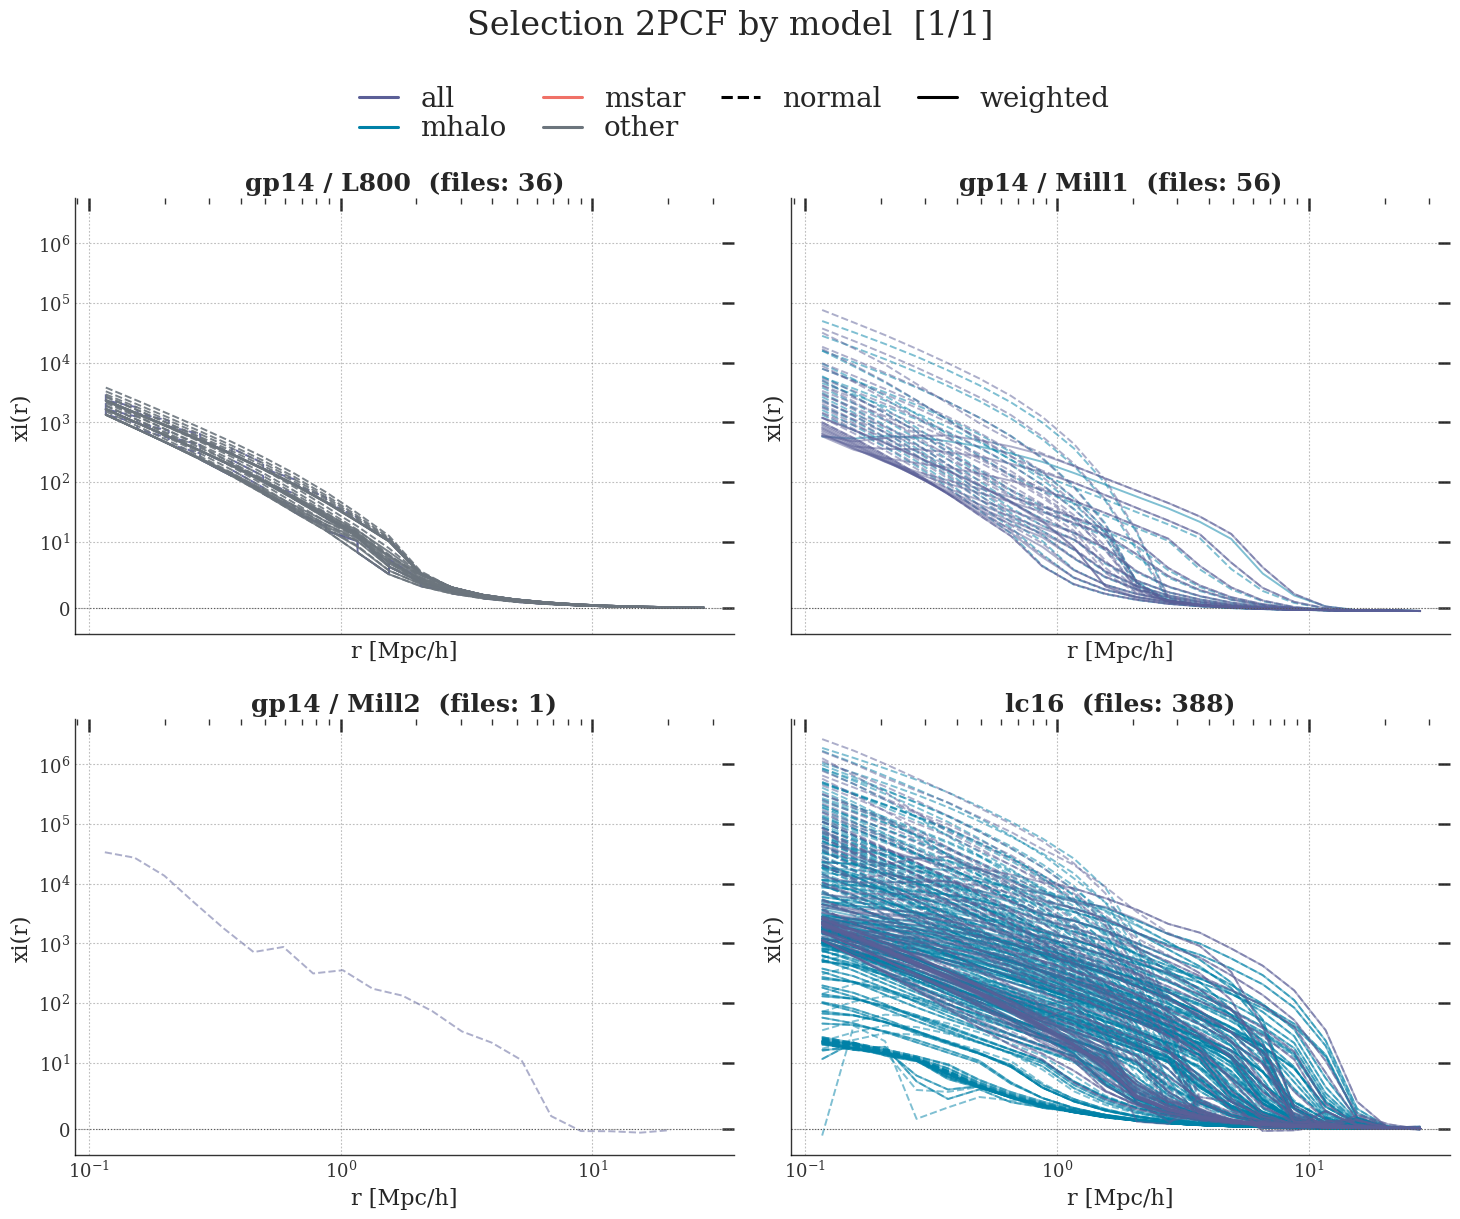

Saved model plots:
/cosma/apps/durham/dc-hick2/galform_analysis/examples/subvolume_statistics/_plots/selection_2pcf_overview/model_2pcf_page1.png


In [41]:
from matplotlib.lines import Line2D
import math

if not master_table.empty:
    master_table["model_panel"] = np.where(
        master_table["model"].eq("gp14"),
        master_table["model"] + " / " + master_table["variant"],
        master_table["model"],
    )
    master_table["selection_panel"] = np.where(
        master_table["selection_kind_group"].isin(["mhalo", "mstar"]),
        master_table["selection_kind"],
        np.where(master_table["selection_path"].eq(""), "all", master_table["selection_path"]),
    )
    master_table["n_label"] = np.where(master_table["n_subvol"] > 0, master_table["n_subvol"].astype(str), "reference")
else:
    master_table["model_panel"] = pd.Series(dtype="object")
    master_table["selection_panel"] = pd.Series(dtype="object")
    master_table["n_label"] = pd.Series(dtype="object")


SECTION_PALETTE = {
    "all": "#5B5F97",
    "mhalo": "#0081A7",
    "mstar": "#F07167",
    "other": "#6C757D",
}
MODE_STYLES = {"normal": "--", "weighted": "-"}


def chunk_values(values, chunk_size):
    for start in range(0, len(values), chunk_size):
        yield values[start:start + chunk_size]



def plot_panel_grid(frame, facet_col, title, output_stem, max_panels=6):
    if frame.empty:
        print(f"No rows available for {title}")
        return []

    facet_values = [value for value in sorted(frame[facet_col].dropna().unique()) if str(value).strip()]
    if not facet_values:
        print(f"No facet values available for {title}")
        return []

    outputs = []
    for page_index, page_values in enumerate(chunk_values(facet_values, max_panels), start=1):
        ncols = 2 if len(page_values) > 1 else 1
        nrows = math.ceil(len(page_values) / ncols)
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(7.5 * ncols, 5.8 * nrows))
        axes = np.array(axes, ndmin=1).reshape(nrows, ncols)

        for ax in axes.flat:
            ax.set_visible(False)

        for ax, facet_value in zip(axes.flat, page_values):
            facet_frame = frame.loc[frame[facet_col] == facet_value].sort_values(["csv_path", "bin_idx"])
            line_total = 0
            for _, file_frame in facet_frame.groupby("csv_path", sort=False):
                file_frame = file_frame.sort_values("r")
                selection_group = file_frame["selection_kind_group"].iloc[0]
                mode = file_frame["mode"].iloc[0]
                color = SECTION_PALETTE.get(selection_group, SECTION_PALETTE["other"])
                linestyle = MODE_STYLES.get(mode, "-")
                alpha = 0.9 if file_frame["n_subvol"].iloc[0] <= 0 else 0.5
                label = None
                if line_total < 10:
                    label = f"{file_frame['selection_panel'].iloc[0]} | {mode} | n={file_frame['n_label'].iloc[0]}"
                ax.plot(file_frame["r"], file_frame["xi"], color=color, ls=linestyle, alpha=alpha, lw=1.4, label=label)
                line_total += 1

            ax.axhline(0.0, color="0.35", lw=0.8, ls=":")
            ax.set_xscale("log")
            ax.set_yscale("symlog", linthresh=1e1)
            ax.set_title(f"{facet_value}  (files: {line_total})")
            ax.set_xlabel("r [Mpc/h]")
            ax.set_ylabel("xi(r)")
            ax.set_visible(True)

        for ax in axes.flat[len(page_values):]:
            ax.set_visible(False)

        proxy_handles = [
            Line2D([0], [0], color=color, lw=2.2, label=label)
            for label, color in SECTION_PALETTE.items()
        ] + [
            Line2D([0], [0], color="black", lw=2.2, ls=style, label=label)
            for label, style in MODE_STYLES.items()
        ]
        fig.legend(handles=proxy_handles, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))
        fig.suptitle(f"{title}  [{page_index}/{math.ceil(len(facet_values) / max_panels)}]", y=1.06)
        fig.tight_layout()

        output_path = PLOT_ROOT / f"{output_stem}_page{page_index}.png"
        fig.savefig(output_path, dpi=220, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        outputs.append(output_path)

    return outputs


model_plot_outputs = plot_panel_grid(
    master_table,
    facet_col="model_panel",
    title="Selection 2PCF by model",
    output_stem="model_2pcf",
)
print("Saved model plots:")
for output_path in model_plot_outputs:
    print(output_path)

## 5. Plot 2PCF for Halo Mass Cuts

The halo-mass section isolates `mhalo*` families so the same plotting rules can be applied across the different mass-bin selections.

,model_panel,selection_panel,mode,variant,iz,n_subvol,csv_relpath
360,gp14 / Mill1,mhalo1e10_all,weighted,Mill1,33,1,group_sampling_halo_filter_sets/gp14/mhalo1e10...
60,gp14 / Mill1,mhalo1e10_all,normal,Mill1,33,2,group_sampling_halo_filter_sets/gp14/mhalo1e10...
140,gp14 / Mill1,mhalo1e10_all,normal,Mill1,33,4,group_sampling_halo_filter_sets/gp14/mhalo1e10...
220,gp14 / Mill1,mhalo1e10_all,normal,Mill1,33,8,group_sampling_halo_filter_sets/gp14/mhalo1e10...
20,gp14 / Mill1,mhalo1e10_all,normal,Mill1,33,10,group_sampling_halo_filter_sets/gp14/mhalo1e10...
40,gp14 / Mill1,mhalo1e10_all,normal,Mill1,33,15,group_sampling_halo_filter_sets/gp14/mhalo1e10...
80,gp14 / Mill1,mhalo1e10_all,normal,Mill1,33,20,group_sampling_halo_filter_sets/gp14/mhalo1e10...
100,gp14 / Mill1,mhalo1e10_all,normal,Mill1,33,25,group_sampling_halo_filter_sets/gp14/mhalo1e10...
120,gp14 / Mill1,mhalo1e10_all,normal,Mill1,33,30,group_sampling_halo_filter_sets/gp14/mhalo1e10...
160,gp14 / Mill1,mhalo1e10_all,normal,Mill1,33,40,group_sampling_halo_filter_sets/gp14/mhalo1e10...


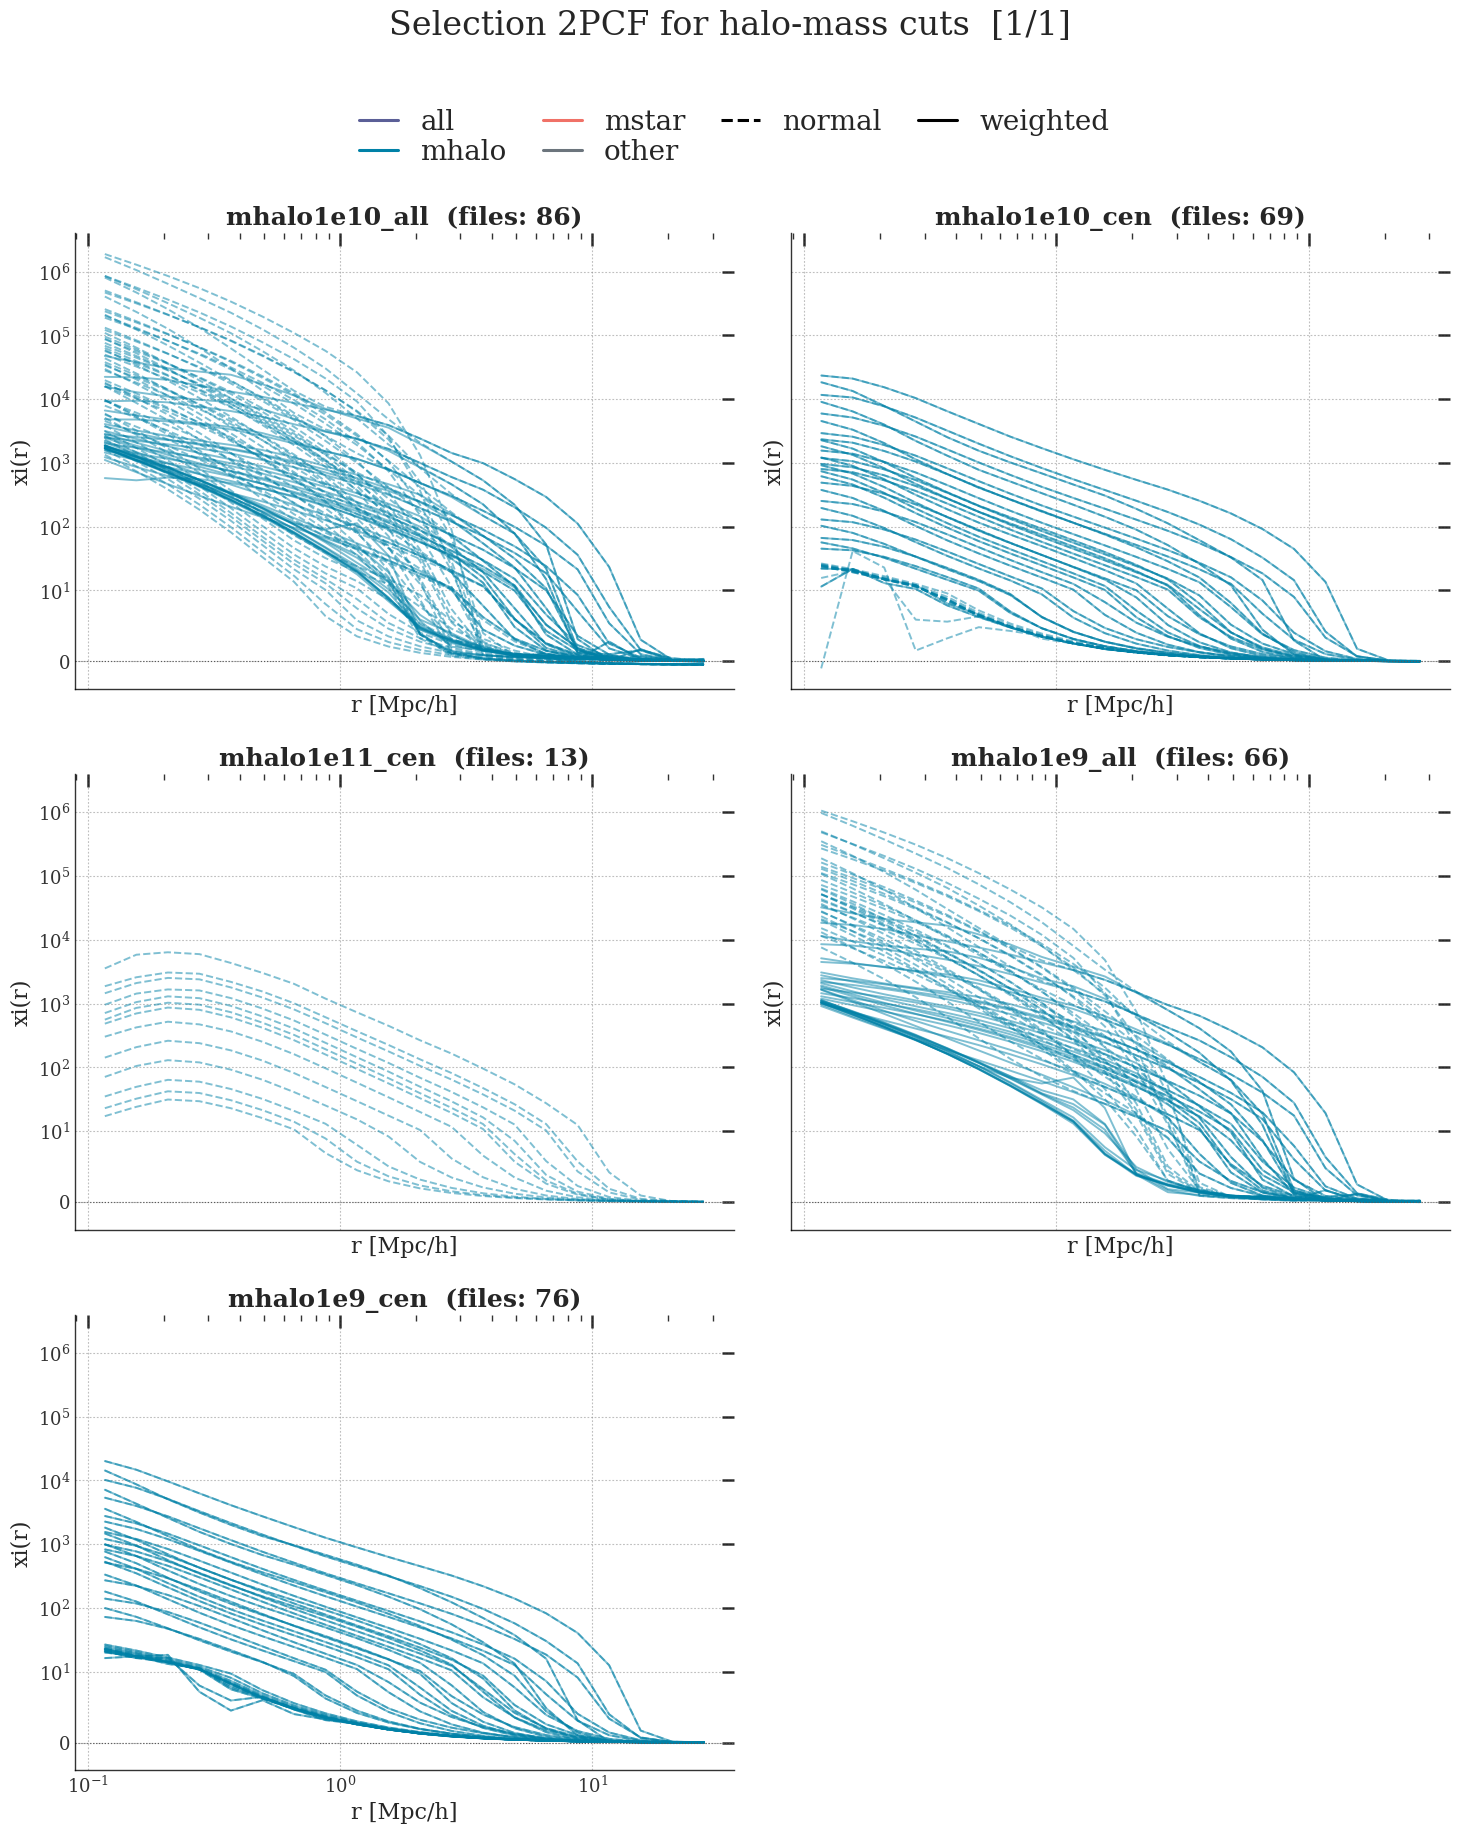

Saved halo-mass-cut plots:
/cosma/apps/durham/dc-hick2/galform_analysis/examples/subvolume_statistics/_plots/selection_2pcf_overview/halo_mass_cuts_2pcf_page1.png


In [42]:
halo_cut_table = master_table.loc[master_table["selection_kind_group"] == "mhalo"].copy()
display(
    halo_cut_table[["model_panel", "selection_panel", "mode", "variant", "iz", "n_subvol", "csv_relpath"]]
    .drop_duplicates()
    .sort_values(["model_panel", "selection_panel", "variant", "iz", "n_subvol"])
    .head(50)
)

halo_plot_outputs = plot_panel_grid(
    halo_cut_table,
    facet_col="selection_panel",
    title="Selection 2PCF for halo-mass cuts",
    output_stem="halo_mass_cuts_2pcf",
)
print("Saved halo-mass-cut plots:")
for output_path in halo_plot_outputs:
    print(output_path)

## 6. Plot 2PCF for Stellar Mass Cuts

The stellar-mass section isolates `mstar*` families and uses the same layout so the different cuts can be compared directly.

In [43]:
stellar_cut_table = master_table.loc[master_table["selection_kind_group"] == "mstar"].copy()
display(
    stellar_cut_table[["model_panel", "selection_panel", "mode", "variant", "iz", "n_subvol", "csv_relpath"]]
    .drop_duplicates()
    .sort_values(["model_panel", "selection_panel", "variant", "iz", "n_subvol"])
    .head(50)
)

stellar_plot_outputs = plot_panel_grid(
    stellar_cut_table,
    facet_col="selection_panel",
    title="Selection 2PCF for stellar-mass cuts",
    output_stem="stellar_mass_cuts_2pcf",
)
print("Saved stellar-mass-cut plots:")
for output_path in stellar_plot_outputs:
    print(output_path)

,model_panel,selection_panel,mode,variant,iz,n_subvol,csv_relpath


No rows available for Selection 2PCF for stellar-mass cuts
Saved stellar-mass-cut plots:


## 7. Plot 2PCF for Other Selection Cuts

Any remaining selection categories, including reference-style or alternative sample definitions, are grouped here so nothing is dropped from the overview.

,model_panel,selection_panel,mode,variant,iz,n_subvol,csv_relpath
9140,,all,,,-1,-1,group_sampling_jobs/normal/L800/group_sampling...
9180,,all,,,-1,-1,group_sampling_jobs/normal/L800/group_sampling...
9220,,all,,,-1,-1,group_sampling_jobs/normal/L800/group_sampling...
9260,,all,,,-1,-1,group_sampling_jobs/weighted/L800/group_sampli...
9300,,all,,,-1,-1,group_sampling_jobs/weighted/L800/group_sampli...
9340,,all,,,-1,-1,group_sampling_jobs/weighted/L800/group_sampli...
9980,,all,,,-1,-1,group_sampling_jobs_by_nvol/n1024/normal/L800/...
10000,,all,,,-1,-1,group_sampling_jobs_by_nvol/n1024/normal/L800/...
10020,,all,,,-1,-1,group_sampling_jobs_by_nvol/n1024/normal/L800/...
10040,,all,,,-1,-1,group_sampling_jobs_by_nvol/n1024/weighted/L80...


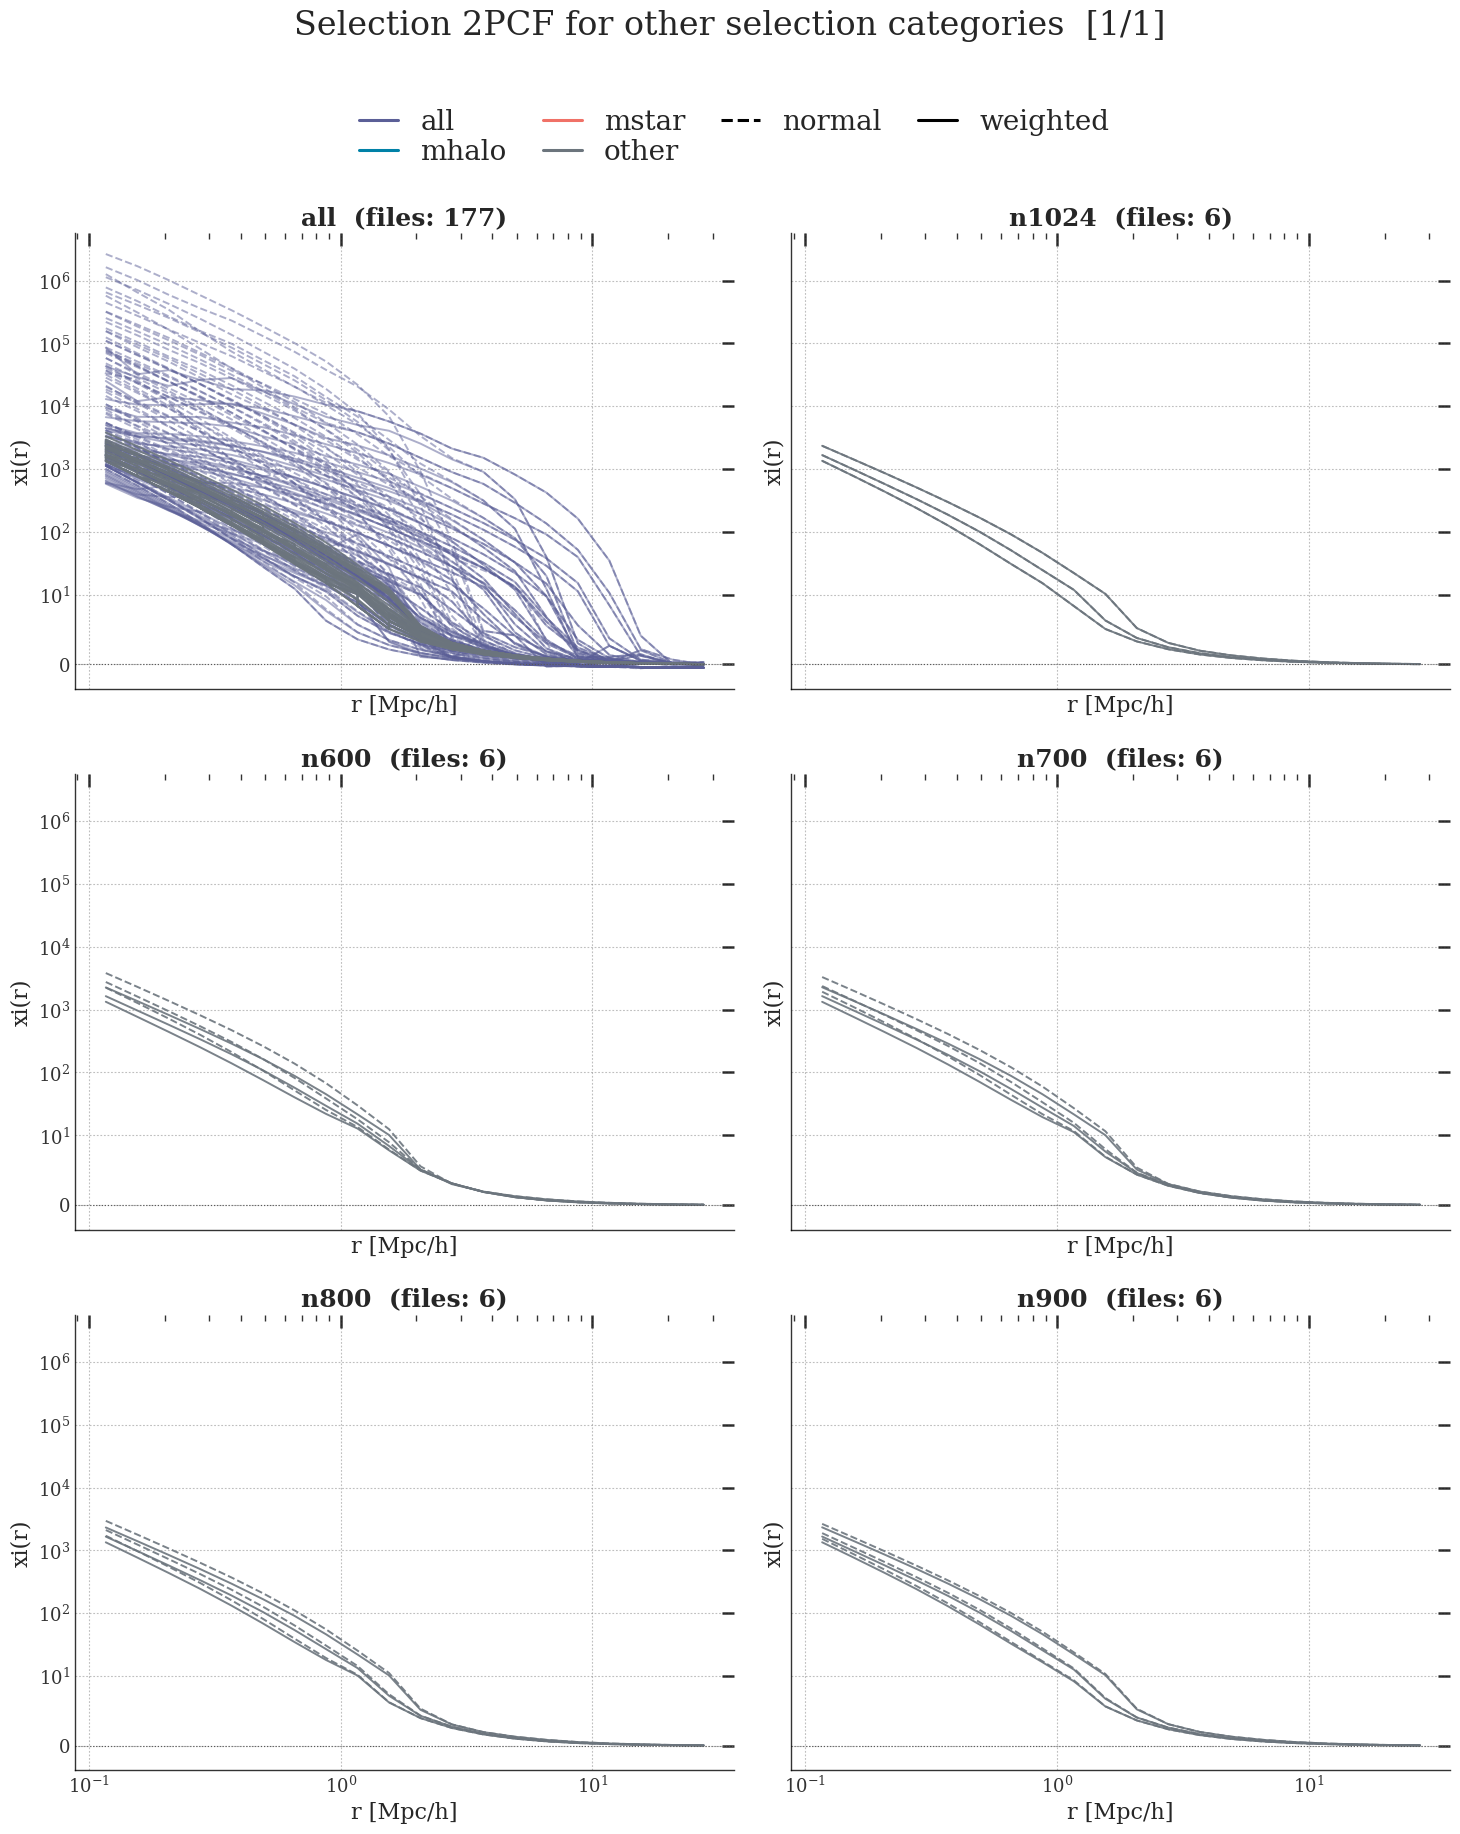

Saved other-selection plots:
/cosma/apps/durham/dc-hick2/galform_analysis/examples/subvolume_statistics/_plots/selection_2pcf_overview/other_selection_2pcf_page1.png


In [44]:
other_cut_table = master_table.loc[~master_table["selection_kind_group"].isin(["mhalo", "mstar"])].copy()
display(
    other_cut_table[["model_panel", "selection_panel", "mode", "variant", "iz", "n_subvol", "csv_relpath"]]
    .drop_duplicates()
    .sort_values(["model_panel", "selection_panel", "variant", "iz", "n_subvol"])
    .head(50)
)

other_plot_outputs = plot_panel_grid(
    other_cut_table,
    facet_col="selection_panel",
    title="Selection 2PCF for other selection categories",
    output_stem="other_selection_2pcf",
)
print("Saved other-selection plots:")
for output_path in other_plot_outputs:
    print(output_path)

## 8. Save Figures and Summary Tables

The notebook writes plot images and compact audit tables into the `examples/subvolume_statistics/_plots/selection_2pcf_overview` directory so the results can be reused outside the notebook.

In [45]:
all_plot_outputs = []
for output_group in [model_plot_outputs, halo_plot_outputs, stellar_plot_outputs, other_plot_outputs]:
    all_plot_outputs.extend(output_group)

if file_audit.empty:
    print("No CSV files were loaded, so there is nothing to save.")
else:
    file_summary = file_audit.merge(
        series_audit[["series_key", "audit_status", "missing_n_count", "missing_n_subvol", "n_subvol_values"]],
        on="series_key",
        how="left",
    ).copy()
    file_summary["category"] = file_summary["selection_kind_group"]
    file_summary["job_completed_successfully"] = file_summary["is_complete_file"] & file_summary["audit_status"].isin(["complete-grid", "reference-only"])
    file_summary = file_summary[
        [
            "csv_relpath",
            "csv_path",
            "root_group",
            "model",
            "mode",
            "variant",
            "selection_path",
            "selection_kind",
            "selection_kind_group",
            "category",
            "iz",
            "n_subvol",
            "job_completed_successfully",
            "audit_status",
            "missing_n_count",
            "missing_n_subvol",
        ]
    ].sort_values(["model", "selection_kind_group", "variant", "iz", "n_subvol", "csv_relpath"])

    file_summary_path = PLOT_ROOT / "selection_2pcf_file_summary.csv"
    series_summary_path = PLOT_ROOT / "selection_2pcf_series_summary.csv"
    master_path = PLOT_ROOT / "selection_2pcf_master_table.csv"

    file_summary.to_csv(file_summary_path, index=False)
    series_audit.to_csv(series_summary_path, index=False)
    master_table.to_csv(master_path, index=False)

    display(file_summary.head(25))
    print(f"Saved {len(all_plot_outputs)} plot files to {PLOT_ROOT}")
    print(f"Saved file summary: {file_summary_path}")
    print(f"Saved series summary: {series_summary_path}")
    print(f"Saved master table: {master_path}")

,csv_relpath,csv_path,root_group,model,mode,variant,selection_path,selection_kind,selection_kind_group,category,iz,n_subvol,job_completed_successfully,audit_status,missing_n_count,missing_n_subvol
451,group_sampling_jobs/normal/L800/group_sampling...,/cosma/apps/durham/dc-hick2/galform_analysis/d...,group_sampling_jobs,,,,,other,other,other,-1,-1,True,reference-only,18,"[1, 2, 4, 8, 10, 15, 20, 25, 30, 40, 50, 64, 1..."
452,group_sampling_jobs/normal/L800/group_sampling...,/cosma/apps/durham/dc-hick2/galform_analysis/d...,group_sampling_jobs,,,,,other,other,other,-1,-1,True,reference-only,18,"[1, 2, 4, 8, 10, 15, 20, 25, 30, 40, 50, 64, 1..."
453,group_sampling_jobs/normal/L800/group_sampling...,/cosma/apps/durham/dc-hick2/galform_analysis/d...,group_sampling_jobs,,,,,other,other,other,-1,-1,True,reference-only,18,"[1, 2, 4, 8, 10, 15, 20, 25, 30, 40, 50, 64, 1..."
454,group_sampling_jobs/weighted/L800/group_sampli...,/cosma/apps/durham/dc-hick2/galform_analysis/d...,group_sampling_jobs,,,,,other,other,other,-1,-1,True,reference-only,18,"[1, 2, 4, 8, 10, 15, 20, 25, 30, 40, 50, 64, 1..."
455,group_sampling_jobs/weighted/L800/group_sampli...,/cosma/apps/durham/dc-hick2/galform_analysis/d...,group_sampling_jobs,,,,,other,other,other,-1,-1,True,reference-only,18,"[1, 2, 4, 8, 10, 15, 20, 25, 30, 40, 50, 64, 1..."
456,group_sampling_jobs/weighted/L800/group_sampli...,/cosma/apps/durham/dc-hick2/galform_analysis/d...,group_sampling_jobs,,,,,other,other,other,-1,-1,True,reference-only,18,"[1, 2, 4, 8, 10, 15, 20, 25, 30, 40, 50, 64, 1..."
487,group_sampling_jobs_by_nvol/n1024/normal/L800/...,/cosma/apps/durham/dc-hick2/galform_analysis/d...,group_sampling_jobs_by_nvol,,,,,other,other,other,-1,-1,True,reference-only,18,"[1, 2, 4, 8, 10, 15, 20, 25, 30, 40, 50, 64, 1..."
488,group_sampling_jobs_by_nvol/n1024/normal/L800/...,/cosma/apps/durham/dc-hick2/galform_analysis/d...,group_sampling_jobs_by_nvol,,,,,other,other,other,-1,-1,True,reference-only,18,"[1, 2, 4, 8, 10, 15, 20, 25, 30, 40, 50, 64, 1..."
489,group_sampling_jobs_by_nvol/n1024/normal/L800/...,/cosma/apps/durham/dc-hick2/galform_analysis/d...,group_sampling_jobs_by_nvol,,,,,other,other,other,-1,-1,True,reference-only,18,"[1, 2, 4, 8, 10, 15, 20, 25, 30, 40, 50, 64, 1..."
490,group_sampling_jobs_by_nvol/n1024/weighted/L80...,/cosma/apps/durham/dc-hick2/galform_analysis/d...,group_sampling_jobs_by_nvol,,,,,other,other,other,-1,-1,True,reference-only,18,"[1, 2, 4, 8, 10, 15, 20, 25, 30, 40, 50, 64, 1..."


Saved 3 plot files to /cosma/apps/durham/dc-hick2/galform_analysis/examples/subvolume_statistics/_plots/selection_2pcf_overview
Saved file summary: /cosma/apps/durham/dc-hick2/galform_analysis/examples/subvolume_statistics/_plots/selection_2pcf_overview/selection_2pcf_file_summary.csv
Saved series summary: /cosma/apps/durham/dc-hick2/galform_analysis/examples/subvolume_statistics/_plots/selection_2pcf_overview/selection_2pcf_series_summary.csv
Saved master table: /cosma/apps/durham/dc-hick2/galform_analysis/examples/subvolume_statistics/_plots/selection_2pcf_overview/selection_2pcf_master_table.csv


## 9. Convergence to Full Box and Difference Plots

For each combination (model, selection, etc.), we plot:
- The convergence of the 2PCF as more subvolumes are added (compared to the full box)
- The difference from the full box in a subplot below

All plots use the custom matplotlib style via `setconfig`.

In [50]:
import sys
import os
# ensure we can import galform_analysis
src_path = os.path.abspath("../../src")
if src_path not in sys.path:
    sys.path.append(src_path)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from galform_analysis.utils import setconfig
setconfig()

def plot_convergence_to_full_box(master_table, output_dir, group_cols=["model", "mode", "variant", "selection_path", "iz"]):
    """
    For each combination of parameters, plots the 2PCF curve for the full box (smallest n_subvol)
    and then plots convergence lines for larger subvol, along with a difference subplot.
    """
    outputs = []
    # Drop rows where essential cols are missing, to avoid weird grouping
    valid_df = master_table.dropna(subset=["r", "xi", "n_subvol"])
    families = valid_df.groupby(group_cols, dropna=False)
    
    for family_key, family_df in families:
        min_n = family_df["n_subvol"].min()
        
        # Reference (full box) -> min n_subvol
        ref_df = family_df[family_df["n_subvol"] == min_n].sort_values("r")
        
        # Subvolumes -> n_subvol > min_n
        sub_df = family_df[family_df["n_subvol"] > min_n]
        if sub_df.empty: # Only full box available
            continue
            
        ref_r = ref_df["r"].values
        ref_xi = ref_df["xi"].values
        
        subvol_groups = sub_df.groupby("n_subvol")
        
        # Prepare figure
        fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8), gridspec_kw={"height_ratios": [2.5, 1]})
        
        cmap = plt.cm.viridis
        n_groups = len(subvol_groups)
        colors = [cmap(i) for i in np.linspace(0, 0.9, n_groups)]
        
        # Plot subvolumes and differences
        for (n_sub, grp_df), color in zip(subvol_groups, colors):
            grp_df = grp_df.sort_values("r")
            
            label = f"$N_{{sub}}={n_sub}$"
            ax1.plot(grp_df["r"], grp_df["xi"], label=label, alpha=0.8, color=color)
            
            # Simple interpolation to reference r in case bins don't match exactly
            # But normally they match exactly. We use direct difference if lengths match.
            if np.array_equal(grp_df["r"].values, ref_r):
                diff = grp_df["xi"].values - ref_xi
                ax2.plot(grp_df["r"], diff, label=label, alpha=0.8, color=color)
            else:
                interp_xi = np.interp(grp_df["r"], ref_r, ref_xi)
                diff = grp_df["xi"].values - interp_xi
                ax2.plot(grp_df["r"], diff, label=label, alpha=0.8, color=color)
            
        # Plot reference
        ref_label = "Full box" if min_n <= 1 else f"Reference ($N_{{sub}}={min_n}$)"
        ax1.plot(ref_r, ref_xi, color="k", lw=2, label=ref_label, zorder=10, linestyle='--')
        ax2.axhline(0, color="k", lw=1.5, linestyle='--', zorder=10)
        
        # Formatting
        title_str = " | ".join([str(k) for k in family_key if pd.notna(k) and str(k) != "" and str(k) != "-1"])
        ax1.set_title(f"Convergence to Full Box: {title_str}", fontsize=14)
        
        ax1.set_ylabel(r"$\xi(r)$")
        ax1.set_yscale("log")
        ax1.set_xscale("log")
        
        ax2.set_xlabel(r"$r \ [h^{-1}\mathrm{Mpc}]$")
        ax2.set_ylabel(r"$\Delta\xi$")
        
        # trim legend if needed
        if n_groups <= 10:
            ax1.legend(fontsize=10, loc="upper right", bbox_to_anchor=(1.25, 1.0))
        else:
            handles, labels = ax1.get_legend_handles_labels()
            # keep full box + a few representative ones
            idx = np.linspace(0, len(handles)-2, 5).astype(int).tolist() + [len(handles)-1]
            sel_handles = [handles[i] for i in idx]
            sel_labels = [labels[i] for i in idx]
            ax1.legend(sel_handles, sel_labels, fontsize=10, loc="upper right", bbox_to_anchor=(1.25, 1.0))

        plt.tight_layout()
        
        # Save output
        outstem = "conv_diff_" + "_".join([str(k) for k in family_key if pd.notna(k) and str(k) != ""]).replace("/", "-").replace(" ", "_")
        outpath = output_dir / f"{outstem}.png"
        fig.savefig(outpath, bbox_inches='tight')
        plt.close(fig)
        outputs.append(outpath)
        
    return outputs

# Run for all families
if "master_table" in locals() and not master_table.empty:
    convergence_outputs = plot_convergence_to_full_box(master_table, PLOT_ROOT)
    print(f"Saved {len(convergence_outputs)} convergence/difference plots to {PLOT_ROOT}")

Saved 37 convergence/difference plots to /cosma/apps/durham/dc-hick2/galform_analysis/examples/subvolume_statistics/_plots/selection_2pcf_overview
